# Notebook 5: Human-in-the-Loop Override

Applies an operator priority override (Economy -> Sustainability, and a second
scenario, Sustainability -> Reliability) to trained Configuration C and D
policies on an identical held-out test episode, and compares:

- Adaptation latency (how fast weights reach the new target)
- Behavioral shift (how per-objective rewards change before/after)
- Behavioral smoothness (how erratic actions are during the transition)
- The weight trajectory itself, overlaid for C vs D

This is the direct empirical test of the report's claim that AMORM's continuous
adaptation (D) responds more smoothly than discrete threshold-switching (C).

In [27]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.distributions import Categorical
from pathlib import Path

In [28]:
# Load environment, data, and calibrated reward norms

from microgrid_env import MicrogridEnv, AGENTS, calibrate_reward_norms, get_electricity_price, get_carbon_intensity, df

PROJ_DIR = Path(r"C:\Users\prish\building-data-genome-project-2")
RESULTS_DIR = PROJ_DIR / "results"

stats = calibrate_reward_norms(lambda: MicrogridEnv(data=df, episode_length=24))
COST_NORM = stats["raw_cost"]["p90"]
EMISSIONS_NORM = stats["raw_emissions"]["p90"]

raw_cost: p50=0.0498  p90=0.1476  p99=0.2661  max=0.3558
raw_emissions: p50=0.3314  p90=1.0891  p99=1.3468  max=1.7778
deviation: p50=0.6528  p90=0.9573  p99=1.1180  max=1.2431


Weight Configuration for C and D:

weights_config_C here calls get_target_weights() directly (which now checks operator_mode first) instead of re-implementing the threshold logic inline. This is what makes a fair C-vs-D comparison possible — without this, an operator override would have literally no effect on Config C (since the original C only reacts to grid-state signals), and you'd have nothing to compare D's smooth response against.

In [29]:
# Weight-config functions (with operator-mode patch for BOTH C and D)

TARGET_WEIGHTS = {
    "economy":        np.array([0.6, 0.2, 0.2], dtype=np.float32),
    "sustainability": np.array([0.2, 0.6, 0.2], dtype=np.float32),
    "emergency":      np.array([0.2, 0.2, 0.6], dtype=np.float32),
}

def get_grid_state_signals(env):
    row = env.data.iloc[env.current_step]
    total_demand = row["building_a"] + row["building_b"]
    L = min(env.grid_import, 1.0)
    G = min(row["solar"] / max(total_demand, 1e-6), 1.0)
    P = get_carbon_intensity(row["solar"])
    return L, G, P

def get_target_weights(env):
    """
    Patched to react to operator_mode FIRST, falling back to grid-state
    thresholds otherwise. Used by BOTH Config C and D below, so an operator
    override has a real, comparable effect on each.
    """
    if env.operator_mode == env.operator_modes["sustainability"]:
        return TARGET_WEIGHTS["sustainability"]
    elif env.operator_mode == env.operator_modes["reliability"]:
        return TARGET_WEIGHTS["emergency"]
    L, G, P = get_grid_state_signals(env)
    if L > 0.7:
        return TARGET_WEIGHTS["emergency"]
    elif G > 0.5 or P > 0.6:
        return TARGET_WEIGHTS["sustainability"]
    else:
        return TARGET_WEIGHTS["economy"]

def weights_config_C(env, prev_weights):
    """Configuration C — Discrete Adaptive: jumps instantly to the target."""
    return get_target_weights(env)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def weights_config_D(env, prev_weights, alpha=0.3, prev_L_smooth=[None]):
    """Configuration D — AMORM Continuous: smooth sigmoid-scaled interpolation."""
    L, G, P = get_grid_state_signals(env)
    target = get_target_weights(env)

    if prev_L_smooth[0] is None:
        L_smooth = L
        delta_L = 0.0
    else:
        L_smooth = 0.8 * prev_L_smooth[0] + 0.2 * L
        delta_L = abs(L_smooth - prev_L_smooth[0])
    prev_L_smooth[0] = L_smooth

    step_size = alpha * sigmoid(delta_L)
    new_weights = prev_weights + step_size * (target - prev_weights)
    new_weights = np.clip(new_weights, 1e-3, None)
    return (new_weights / new_weights.sum()).astype(np.float32)

In [30]:
# Rebuild networks and load trained policies

class Actor(nn.Module):
    def __init__(self, obs_dim=11, action_dim=3, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
    def forward(self, obs):
        return Categorical(logits=self.net(obs))


def load_policy(result, agents, device="cpu"):
    actors = {}
    for agent in agents:
        actor = Actor().to(device)
        actor.load_state_dict(result["actors_state_dict"][agent])
        actor.eval()
        actors[agent] = actor
    return actors


all_results = torch.load(RESULTS_DIR / "training_results.pt", weights_only=False)

def get_result(config_name, seed):
    return next(r for r in all_results if r["config"] == config_name and r["seed"] == seed)

In [31]:
# Fixed test episode window

TEST_EPISODE_LENGTH = 168   # 7 days

def make_test_env(start_step=None):
    env = MicrogridEnv(data=df, episode_length=TEST_EPISODE_LENGTH,
                        cost_norm=COST_NORM, emissions_norm=EMISSIONS_NORM)
    if start_step is None:
        start_step = len(df) - TEST_EPISODE_LENGTH - 1
    env.episode_start = start_step
    env.current_step = start_step
    return env

Generalized override-episode runner: 

Functions used:
- dist.probs.argmax() — deterministic evaluation, same as Notebook 4.
- weight_fn is weights_config_D — dispatches to the right call signature (D needs prev_L_smooth, C doesn't), so this one function runs the override for either config.
Everything else mirrors Notebook 4's run_human_override_episode, generalized to take start_mode/target_mode/config_name/seed as parameters instead of being hardcoded to one scenario.

In [32]:
# Generalized override-episode runner

def run_override_episode(config_name, seed, weight_fn, start_mode, target_mode,
                          switch_step=72, device="cpu"):
    """
    Runs a trained policy on the fixed test episode, starting in `start_mode`
    and switching to `target_mode` at `switch_step`. Works for both Config C
    (instant jump) and Config D (smooth interpolation) since both now read
    operator_mode via get_target_weights().
    """
    result = get_result(config_name, seed)
    env = make_test_env()
    actors = load_policy(result, env.possible_agents)

    obs, _ = env.reset()
    env.current_step = env.episode_start
    obs = env._get_observations()
    env.operator_mode = env.operator_modes[start_mode]
    env.weights = TARGET_WEIGHTS[start_mode if start_mode != "reliability" else "emergency"].copy()

    prev_L_holder = [None]
    history = []
    done = False
    step_index = 0

    while not done:
        if step_index == switch_step:
            env.operator_mode = env.operator_modes[target_mode]

        actions = {}
        for agent in env.possible_agents:
            obs_tensor = torch.as_tensor(obs[agent], dtype=torch.float32, device=device)
            dist = actors[agent](obs_tensor)
            actions[agent] = int(dist.probs.argmax().item())

        if weight_fn is weights_config_D:
            env.weights = weight_fn(env, env.weights, prev_L_smooth=prev_L_holder)
        else:
            env.weights = weight_fn(env, env.weights)

        next_obs, rewards, terminations, truncations, infos = env.step(actions)
        info = infos[env.possible_agents[0]]
        info["step"] = step_index
        info["weights"] = env.weights.copy()
        history.append(info)

        done = terminations[env.possible_agents[0]] or truncations[env.possible_agents[0]]
        obs = next_obs if not done else obs
        step_index += 1

    return pd.DataFrame(history)

In [33]:
#Run the core comparison: C vs D, Economy → Sustainability

history_C = run_override_episode("C_discrete_adaptive", seed=0, weight_fn=weights_config_C,
                                   start_mode="sustainability", target_mode="reliability", switch_step=72)
history_D = run_override_episode("D_amorm_continuous", seed=0, weight_fn=weights_config_D,
                                   start_mode="sustainability", target_mode="reliability", switch_step=72)

print("C weights at steps 70-78:\n", np.stack(history_C["weights"].values)[70:78])
print("\nD weights at steps 70-78:\n", np.stack(history_D["weights"].values)[70:78])

C weights at steps 70-78:
 [[0.2 0.6 0.2]
 [0.2 0.6 0.2]
 [0.2 0.2 0.6]
 [0.2 0.2 0.6]
 [0.2 0.2 0.6]
 [0.2 0.2 0.6]
 [0.2 0.2 0.6]
 [0.2 0.2 0.6]]

D weights at steps 70-78:
 [[0.2        0.6        0.2       ]
 [0.2        0.6        0.2       ]
 [0.2        0.5399302  0.26006982]
 [0.19999999 0.4888743  0.31112573]
 [0.19999999 0.44544584 0.35455418]
 [0.19999999 0.40842858 0.39157143]
 [0.19999999 0.3767551  0.42324492]
 [0.19999999 0.34993622 0.4500638 ]]


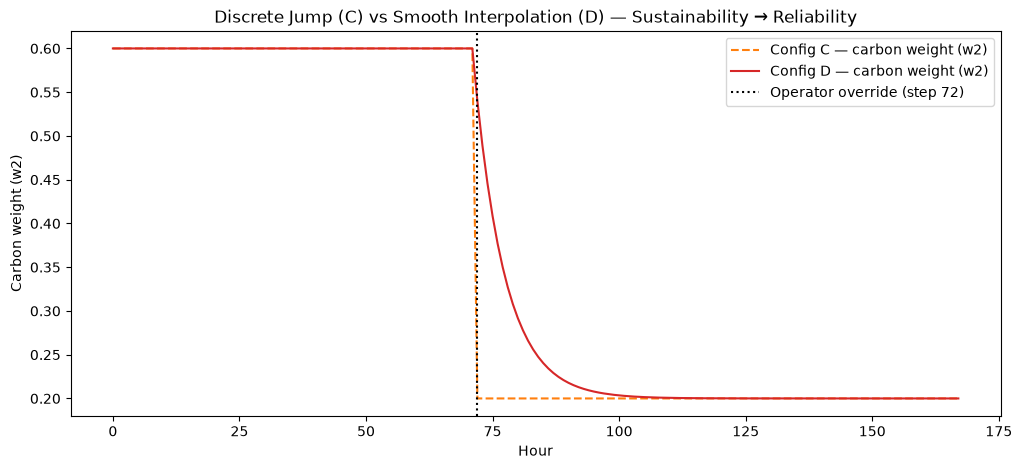

In [34]:
# Overlaid weight trajectory plot

weights_C = np.stack(history_C["weights"].values)
weights_D = np.stack(history_D["weights"].values)
steps = history_C["step"].values

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(steps, weights_C[:, 1], label="Config C — carbon weight (w2)", linestyle="--", color="tab:orange")
ax.plot(steps, weights_D[:, 1], label="Config D — carbon weight (w2)", color="tab:red")
ax.axvline(72, color="black", linestyle=":", label="Operator override (step 72)")
ax.set_xlabel("Hour")
ax.set_ylabel("Carbon weight (w2)")
ax.set_title("Discrete Jump (C) vs Smooth Interpolation (D) — Sustainability \u2192 Reliability")
ax.legend()
plt.show()

In [35]:
# Quantifying latency, shift, and smoothness for both configs

def analyze_override(history, switch_step=72, target_w3=0.6, tolerance=0.05):
    weights = np.stack(history["weights"].values)

    post_switch = weights[switch_step:, 2]
    within_tol = np.where(np.abs(post_switch - target_w3) < tolerance)[0]
    latency = int(within_tol[0]) if len(within_tol) > 0 else None

    before = history.iloc[switch_step - 24:switch_step][["cost_reward", "carbon_reward", "stability_reward"]].mean()
    after = history.iloc[switch_step:switch_step + 24][["cost_reward", "carbon_reward", "stability_reward"]].mean()
    shift = (after - before)

    # Fixed, global threshold computed once from the WHOLE episode,
    # not recomputed per-window — makes "erratic" mean the same thing
    # in both the baseline and transition slices.
    global_thresholds = {}
    for col in ["building_a_demand", "building_b_demand"]:
        global_thresholds[col] = history[col].diff().abs().median() * 2

    def erratic_rate(slice_df):
        count = 0
        for col in ["building_a_demand", "building_b_demand"]:
            diffs = slice_df[col].diff().abs()
            count += int((diffs > global_thresholds[col]).sum())
        return count / len(slice_df) if len(slice_df) > 0 else 0.0

    baseline_rate = erratic_rate(history.iloc[switch_step - 24:switch_step])
    transition_rate = erratic_rate(history.iloc[switch_step:switch_step + 24])

    return {
        "adaptation_latency_steps": latency,
        "cost_reward_shift": round(shift["cost_reward"], 4),
        "carbon_reward_shift": round(shift["carbon_reward"], 4),
        "stability_reward_shift": round(shift["stability_reward"], 4),
        "baseline_erratic_rate": baseline_rate,
        "transition_erratic_rate": transition_rate,
    }

In [36]:
seed_comparisons = []

for seed in [0, 1, 2, 3, 4]:
    hist_c = run_override_episode("C_discrete_adaptive", seed=seed, weight_fn=weights_config_C,
                                start_mode="sustainability", target_mode="reliability", switch_step=72)
    hist_d = run_override_episode("D_amorm_continuous", seed=seed, weight_fn=weights_config_D,
                                start_mode="sustainability", target_mode="reliability", switch_step=72)

    result_c = analyze_override(hist_c)
    result_d = analyze_override(hist_d)
    result_c.update({"config": "C_discrete_adaptive", "seed": seed})
    result_d.update({"config": "D_amorm_continuous", "seed": seed})
    seed_comparisons.append(result_c)
    seed_comparisons.append(result_d)

seed_comparison_df = pd.DataFrame(seed_comparisons)
seed_comparison_df.groupby("config")[
    ["adaptation_latency_steps", "transition_erratic_rate", "baseline_erratic_rate"]
].agg(["mean", "std"])

adaptation_latency_steps      transition_erratic_rate  \
                                        mean  std                    mean   
config                                                                      
C_discrete_adaptive                      0.0  0.0                0.308333   
D_amorm_continuous                      12.0  0.0                0.375000   

                              baseline_erratic_rate            
                          std                  mean       std  
config                                                         
C_discrete_adaptive  0.157564              0.408333  0.154223  
D_amorm_continuous   0.181621              0.291667  0.114109

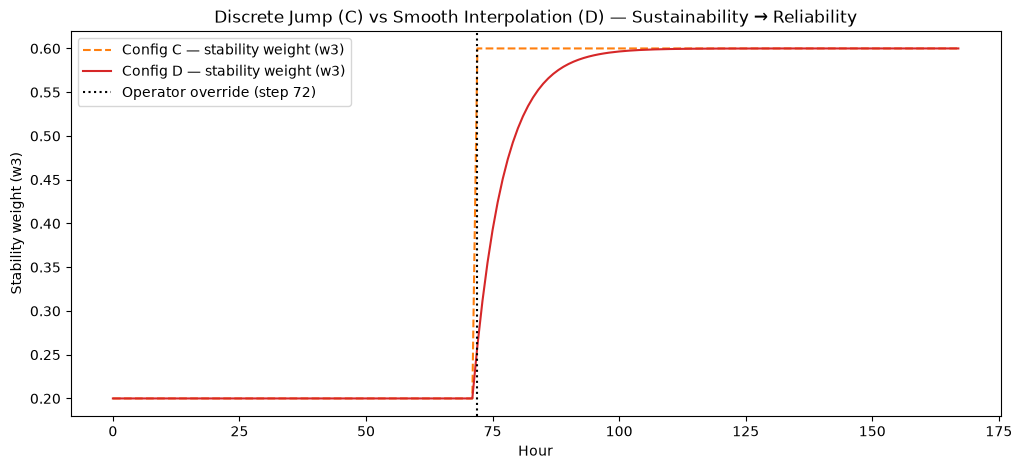

In [37]:
# Second scenario: Sustainability → Reliability (generality check)

history_C_2 = run_override_episode("C_discrete_adaptive", seed=0, weight_fn=weights_config_C,
                                     start_mode="sustainability", target_mode="reliability", switch_step=72)
history_D_2 = run_override_episode("D_amorm_continuous", seed=0, weight_fn=weights_config_D,
                                     start_mode="sustainability", target_mode="reliability", switch_step=72)

weights_C_2 = np.stack(history_C_2["weights"].values)
weights_D_2 = np.stack(history_D_2["weights"].values)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_C_2["step"], weights_C_2[:, 2], label="Config C — stability weight (w3)", linestyle="--", color="tab:orange")
ax.plot(history_D_2["step"], weights_D_2[:, 2], label="Config D — stability weight (w3)", color="tab:red")
ax.axvline(72, color="black", linestyle=":", label="Operator override (step 72)")
ax.set_xlabel("Hour")
ax.set_ylabel("Stability weight (w3)")
ax.set_title("Discrete Jump (C) vs Smooth Interpolation (D) — Sustainability \u2192 Reliability")
ax.legend()
plt.show()

In [38]:
comparison.to_csv(RESULTS_DIR / "human_override_single_seed_comparison.csv")
seed_comparison_df.to_csv(RESULTS_DIR / "human_override_multi_seed_comparison.csv", index=False)